In [15]:
%load_ext autoreload
%autoreload 2

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()

import json

OC = config.OUTRIDER_COMPARISON_DIR
pd.set_option("display.width", 120)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Gene-coverage and CV Z-score-moment sections were removed on 2026-10-01: they read
`gene_coverage_by_expression.csv`, `outrider_coverage_summary.json` and
`outrider_cv_metrics.csv`, none of which any script in this repo produces, so after the
2026-09-30 batch redefinition they would have mixed 2026-08 pre-refit numbers into an
otherwise post-refit notebook. Rebuild the producers before restoring them.

## 1. CV posterior predictive check (PPC): obs vs model-implied mean/std/zero-fraction

In [16]:
eng_ppc = pd.read_csv(config.CV_MIXED_DIR / "cv_calibration_moments.csv").set_index("gene")
outr_ppc = pd.read_csv(OC / "outrider_cv_calibration_moments.csv").set_index("gene")

common_ppc_genes = eng_ppc.index.intersection(outr_ppc.index)
print(f"our engine PPC genes: {len(eng_ppc)} | OUTRIDER PPC genes: {len(outr_ppc)} | common: {len(common_ppc_genes)}")

eng_ppc_full = eng_ppc.median()
eng_ppc_sub = eng_ppc.loc[common_ppc_genes].median()
outr_ppc_med = outr_ppc.median()
ppc_table = pd.DataFrame({
    "our_engine (full 19858g)": eng_ppc_full.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
    "our_engine (12305g subset)": eng_ppc_sub.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
    "outrider (12305g)": outr_ppc_med.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
}, index=["mean (obs)", "mean (pred)", "std (obs)", "std (pred)", "zero-frac (obs)", "zero-frac (pred)"])
ppc_table


our engine PPC genes: 19851 | OUTRIDER PPC genes: 12312 | common: 12312


,our_engine (full 19858g),our_engine (12305g subset),outrider (12305g)
mean (obs),28.415317,106.421208,106.421208
mean (pred),29.516200,108.890876,113.011657
std (obs),67.808085,172.436917,172.436917
std (pred),97.537618,215.176907,213.219974
zero-frac (obs),0.238586,0.058910,0.058910
zero-frac (pred),0.207327,0.037043,0.022430


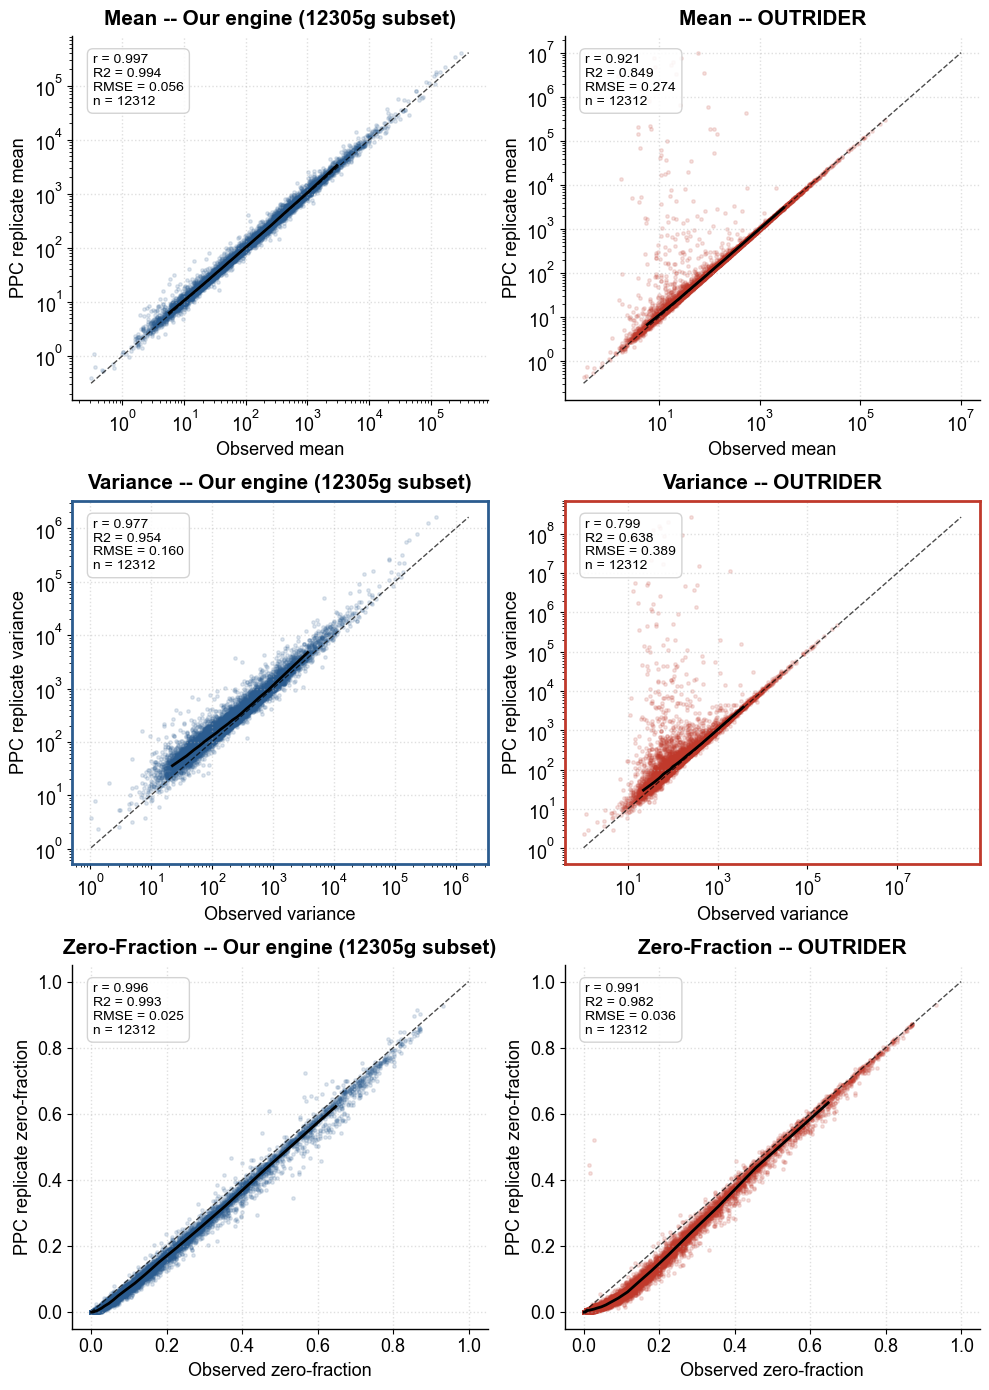

In [17]:
from MixedEffectsModeling.validation.ppc_simulate import binned_medians, calib_stats

eng_sub_cal = pd.read_csv(OC / "our_engine_cv_calibration_moments_12305subset.csv")
outr_cal = pd.read_csv(OC / "outrider_cv_calibration_moments.csv")

panels = [("obs_mean", "pred_mean", "Mean", True), ("obs_var", "pred_var", "Variance", True),
         ("obs_zero", "pred_zero", "Zero-Fraction", False)]
engines = [("Our engine (12305g subset)", eng_sub_cal, "#2b5c8f"), ("OUTRIDER", outr_cal, "#c0392b")]

fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for row, (oc, pc, title_str, logsc) in enumerate(panels):
    xlim = None
    for col, (eng_label, cal, color) in enumerate(engines):
        ax = axes[row, col]
        ax.scatter(cal[oc], cal[pc], s=6, alpha=0.15, color=color)
        bx, by = binned_medians(cal[oc], cal[pc])
        ax.plot(bx, by, '-', color='black', linewidth=2)

        if logsc:
            lo = max(min(cal[oc].min(), cal[pc].min()), 1e-3)
            hi = max(cal[oc].max(), cal[pc].max())
            ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.7)
            ax.set_xscale('log'); ax.set_yscale('log')
        else:
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)

        cs = calib_stats(cal[oc], cal[pc], logsc)
        ax.set_title(f"{title_str} -- {eng_label}", fontweight='bold', pad=8)
        ax.set_xlabel(f'Observed {title_str.lower()}')
        ax.set_ylabel(f'PPC replicate {title_str.lower()}')
        stats_text = "r = {pearson_r:.3f}\nR2 = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {n}".format(**cs)
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4)
        if row == 1:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('#c0392b' if col == 1 else '#2b5c8f')
                spine.set_linewidth(2)

plt.tight_layout()
fig.savefig(OC / 'Figures' / 'ppc_scatter_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### 1a. Gene-level calibration statistics (Pearson r / R2, Spearman rho, RMSE, MAE)

In [18]:
calib = pd.read_csv(OC / "ppc_calib_stats.csv")
calib_wide = calib.pivot(index="panel", columns="engine",
                         values=["pearson_r", "r2", "spearman_rho", "rmse", "mae"])
calib_wide = calib_wide.reindex(["mean", "var", "zero_frac"])
calib_wide = calib_wide.reindex(columns=["our_engine_full19858", "our_engine_12305subset", "outrider_12305"], level=1)
calib_wide

pearson_r                                                         r2                         \
engine    our_engine_full19858 our_engine_12305subset outrider_12305 our_engine_full19858 our_engine_12305subset   
panel                                                                                                              
mean                  0.994669               0.996856       0.921295             0.989367               0.993723   
var                   0.968987               0.976625       0.798634             0.938936               0.953796   
zero_frac             0.999177               0.996459       0.990995             0.998354               0.992931   

                                 spearman_rho                                                       rmse  \
engine    outrider_12305 our_engine_full19858 our_engine_12305subset outrider_12305 our_engine_full19858   
panel                                                                                                      
mean            0.848785             0.994546               0.997333       0.968738             0.108457   
var             0.637816             0.973271               0.975301       0.913163             0.258129   
zero_frac       0.982072             0.998288               0.994501       0.987842             0.021118   

                                                                 mae                                        
engine    our_engine_12305subset outrider_12305 our_engine_full19858 our_engine_12305subset outrider_12305  
panel                                                                                                       
mean                    0.056369       0.274460             0.047817               0.035999       0.045075  
var                     0.160394       0.388710             0.156743               0.117888       0.118207  
zero_frac               0.024646       0.035629             0.015817               0.019676       0.027505

## 2. LOBO: held-out-disease vs held-out-HC

Same criterion as `2_lobo_validation.ipynb` (both call `validation/lobo_mmd.py`): RKHS
kernel-embedding distance to the held-out-HC mean embedding and per-sample BH-significant
gene count, each by one-sided Mann-Whitney with BH across batches, on batches with
`n_hc >= 25` and `n_dis >= 10`, and with Moore_1 restricted to PDAC. Every arm is scored on
the SAME samples (`load_csv_arm` reindexes to the engine arm's names); only the gene sets
differ, which `n_gene` reports.

In [19]:
import pickle as _pkl

from MixedEffectsModeling.validation.lobo_mmd import plot_mmd_direction, short_batch_label
from MixedEffectsModeling.validation import lobo_mmd

HO = config.OUTRIDER_COMPARISON_DIR.parent / 'held_out_comparison'

arms = {'our_engine': lobo_mmd.load_engine_arm(shash=True, ood_filter=True)}
arms['outrider_insample'] = lobo_mmd.load_csv_arm(OC, arms['our_engine'])
arms['outrider_heldout'] = lobo_mmd.load_csv_arm(HO, arms['our_engine'])

# gene-matched engine arm: OUTRIDER drops ~38% of genes at its own FPKM filter, so the
# unmatched comparison confounds method with gene universe
_src = next((d for d in (OC, HO) if arms[f"outrider_{'insample' if d is OC else 'heldout'}"]), None)
if _src is not None:
    gene_names = _pkl.load(open(next(config.LOBO_MIXED_DIR.glob('*/gene_names.pkl')), 'rb'))
    outr_genes = pd.read_csv(next(_src.glob('z_test_*.csv')), index_col=0, nrows=1).columns
    col = np.flatnonzero(np.isin(gene_names, outr_genes))
    arms['our_engine_genematched'] = {b: dict(a, Z=a['Z'][:, col])
                                      for b, a in arms['our_engine'].items()}

dist, raw, nsig = {}, {}, {}
for tag, arm in arms.items():
    if not arm:
        print(f'{tag}: no Z found, skipped (run the OUTRIDER LOBO stages first)')
        continue
    dist[tag], raw[tag] = lobo_mmd.rkhs_stats(arm)
    nsig[tag] = lobo_mmd.nsig_stats(lobo_mmd.nsig_table(arm))

rows = []
for tag in dist:
    d = dist[tag].set_index('batch')
    n = nsig[tag].set_index('batch')
    for b in d.index:
        rows.append(dict(arm=tag, batch=short_batch_label(b), n_gene=d.loc[b, 'n_gene'],
                         dist_auc=d.loc[b, 'auc'], dist_q=d.loc[b, 'bh_q'],
                         nsig_auc=n.loc[b, 'auc'], nsig_q=n.loc[b, 'bh_q']))
cmp = pd.DataFrame(rows)
for tag in dist:
    print(f"{tag:26s} distance q<0.05: {(dist[tag].bh_q < 0.05).sum()}/{len(dist[tag])}   "
          f"n_sig q<0.05: {(nsig[tag].bh_q < 0.05).sum()}/{len(nsig[tag])}")
cmp.pivot(index='batch', columns='arm', values=['dist_auc', 'nsig_auc']).round(3)


our_engine                 distance q<0.05: 5/5   n_sig q<0.05: 5/5
outrider_insample          distance q<0.05: 2/5   n_sig q<0.05: 1/5
outrider_heldout           distance q<0.05: 2/5   n_sig q<0.05: 1/5
our_engine_genematched     distance q<0.05: 3/5   n_sig q<0.05: 2/5


dist_auc                                                             nsig_auc                         \
arm         our_engine our_engine_genematched outrider_heldout outrider_insample our_engine our_engine_genematched   
batch                                                                                                                
Chen_1           0.695                  0.771            0.652             0.636      0.811                  0.758   
Moore_1          0.723                  0.631            0.535             0.545      0.922                  0.633   
Moufarrej_1      0.665                  0.626            0.366             0.453      0.783                  0.579   
Moufarrej_4      0.650                  0.635            0.406             0.415      0.880                  0.673   
Ward Z_1         0.732                  0.874            0.752             0.789      0.778                  0.541   

                                                
arm         outrider_heldout outrider_insample  
batch                                           
Chen_1                 0.664             0.567  
Moore_1                0.535             0.533  
Moufarrej_1            0.541             0.454  
Moufarrej_4            0.379             0.390  
Ward Z_1               0.492             0.713

### 2a. Direction KDE and per-sample n_sig, per arm

`plot_mmd_direction` / `plot_nsig_box` from `validation/lobo_mmd.py` -- the same functions
`2_lobo_validation.ipynb` uses, so the panels are directly comparable.

In [20]:
FIG = OC / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)


In [21]:
for tag in dist:
    plot_mmd_direction(dist[tag], raw[tag], FIG / f'mmd_direction_{tag}.png',
                       p_col='mw_p', sort_col='auc', row_h=1.2)
    lobo_mmd.plot_nsig_box(lobo_mmd.nsig_table(arms[tag]), nsig[tag], tag,
                           FIG / f'nsig_{tag}.png')
    plt.close('all')
